# Estimating the incremental impact of retail promotions

**Data:** Rossmann daily store sales (Kaggle)  
**Question:** Do promotions actually move incremental sales, or do they just line up with periods that would've been strong anyway?

Walks through panel construction, identification issues, and three estimators: two-way FE (store + ISO week), an event-study lead/lag spec, and heterogeneity (promo x store traits).

## 1. Environment and imports

In [6]:
%matplotlib inline

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from linearmodels.panel import PanelOLS

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")



Project root: /Users/zacw/Documents/06_Github - Data Science/promotion-incrementality-causal-inference


In [ ]:
# ---- helpers ----

DATA_RAW = ROOT / "data" / "raw"

def load_and_prepare():
    train = pd.read_csv(DATA_RAW / "train.csv", low_memory=False, parse_dates=["Date"])
    train["StateHoliday"] = train["StateHoliday"].astype(str).str.strip()
    store = pd.read_csv(DATA_RAW / "store.csv")

    train = train.loc[train["Open"] == 1].copy()
    train = train.loc[train["Sales"] > 0].copy()

    store["CompetitionDistance"] = pd.to_numeric(store["CompetitionDistance"], errors="coerce")
    med_cd = store["CompetitionDistance"].median()
    store["CompetitionDistance"] = store["CompetitionDistance"].fillna(med_cd)
    store["high_comp"] = (store["CompetitionDistance"] >= store["CompetitionDistance"].median()).astype(int)
    store["Promo2"] = pd.to_numeric(store["Promo2"], errors="coerce").fillna(0).astype(int)

    df = train.merge(
        store[["Store", "high_comp", "Promo2", "StoreType", "Assortment"]],
        on="Store", how="left", validate="many_to_one",
    )

    df["log_sales"] = np.log(df["Sales"].astype(float))
    df["year_week"] = df["Date"].dt.strftime("%G-%V")
    df["dow"] = df["Date"].dt.dayofweek
    df = df.sort_values(["Store", "Date"]).reset_index(drop=True)
    return df


def add_promo_calendar_leads_lags(df, k=3):
    """National promo schedule: same Promo for all stores on a given date."""
    cal = df[["Date", "Promo"]].drop_duplicates("Date").sort_values("Date")
    cal = cal.set_index("Date")["Promo"]
    out = df.copy()
    for i in range(1, k + 1):
        out[f"promo_lead{i}"] = out["Date"].map(cal.shift(-i))
        out[f"promo_lag{i}"] = out["Date"].map(cal.shift(i))
    for prefix in ("promo_lead", "promo_lag"):
        cols = [c for c in out.columns if c.startswith(prefix)]
        out[cols] = out[cols].fillna(0)
    return out


def fit_panel(df, formula):
    panel = df.set_index(["Store", "Date"])
    other = pd.DataFrame({"year_week": panel["year_week"]}, index=panel.index)
    return PanelOLS.from_formula(formula, data=panel, other_effects=other)

## 2. Load and describe the panel

Keep open days with positive sales (standard for this dataset). Merge store.csv for competition distance and Promo2 flag. Build log_sales, ISO week, day-of-week.

In [7]:
df = load_and_prepare()

print("Rows:", len(df))
print("Stores:", df["Store"].nunique())
print("Date range:", df["Date"].min().date(), "→", df["Date"].max().date())
print("Share of promo days:", df["Promo"].mean().round(3))
df[["Sales", "Customers", "Promo", "log_sales"]].describe().round(2)

Rows: 844338
Stores: 1115
Date range: 2013-01-01 → 2015-07-31
Share of promo days: 0.446


,Sales,Customers,Promo,log_sales
count,844338.00,844338.00,844338.00,844338.00
mean,6955.96,762.78,0.45,8.76
std,3103.82,401.19,0.50,0.43
min,46.00,8.00,0.00,3.83
25%,4859.00,519.00,0.00,8.49
50%,6369.00,676.00,0.00,8.76
75%,8360.00,893.00,1.00,9.03
max,41551.00,7388.00,1.00,10.63


### Promo intensity over time

7-day rolling average of the daily promo indicator. Since promo is national (same for all stores on each date), this is just one series.

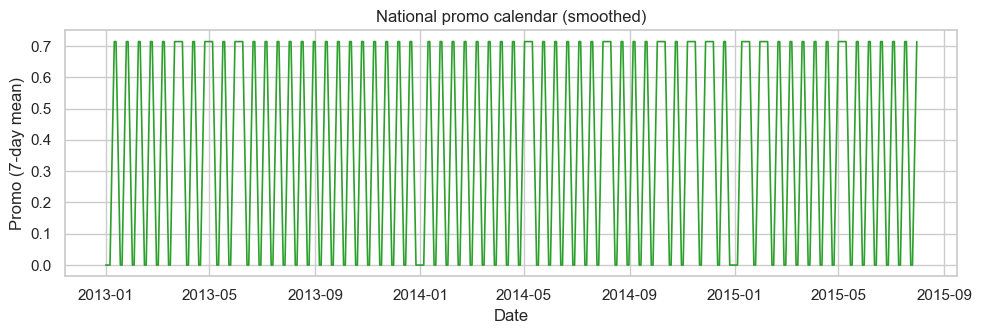

In [8]:
daily = df.groupby("Date", as_index=False)["Promo"].mean()
daily["ma7"] = daily["Promo"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(daily["Date"], daily["ma7"], color="#2ca02c", lw=1.2)
ax.set_ylabel("Promo (7-day mean)")
ax.set_xlabel("Date")
ax.set_title("National promo calendar (smoothed)")
fig.tight_layout()
plt.show()

## 3. Identification: what the data allow

Quick check: on each calendar date, is `Promo` identical across all stores? If so, a full calendar-date FE would absorb `Promo` entirely -- you can't estimate a separate promo coefficient in that spec.

So instead we use store FE + ISO-week FE. Identification comes from within-store, within-week variation (promo-on vs promo-off days in the same ISO week), plus dow and holiday controls. This is a real limitation worth flagging.

In [9]:
by_date = df.groupby("Date")["Promo"].nunique()
assert (by_date <= 1).all()
print("Promo is constant across stores on each date (national schedule).")
print("Max distinct promo values per date:", by_date.max())

Promo is constant across stores on each date (national schedule).
Max distinct promo values per date: 1


## 4. Main specification: two-way FE

Outcome: `log_sales`, treatment: `Promo`  
FE: store (EntityEffects) + ISO week (other_effects)  
Controls: dow, state holiday, school holiday  
SE: clustered by store

In [ ]:
formula_main = (
    "log_sales ~ Promo + C(dow) + C(StateHoliday) + SchoolHoliday + EntityEffects"
)
mod_main = fit_panel(df, formula_main)
res_main = mod_main.fit(cov_type="clustered", cluster_entity=True)

display(res_main.summary.tables[1])
print("Within R²:", round(res_main.rsquared_within, 4))
print("N obs:", int(res_main.nobs))

Under a log outcome, exp(beta)-1 gives you the approximate proportional change in sales. Interpret as associative unless you're willing to defend stronger assumptions about the FE structure.

## 5. Robustness: controlling for log(Customers)

Customer traffic sits on the causal path (promo -> more foot traffic -> more sales), so adding log(Customers) probably soaks up part of the channel. Treat this as a sensitivity check, not the main spec.

In [ ]:
formula_cust = (
    "log_sales ~ Promo + log(Customers) + C(dow) + C(StateHoliday)"
    " + SchoolHoliday + EntityEffects"
)
res_cust = fit_panel(df, formula_cust).fit(cov_type="clustered", cluster_entity=True)
promo_row = pd.DataFrame(
    {
        "spec": ["main", "+ log(Customers)"],
        "Promo_coef": [res_main.params["Promo"], res_cust.params["Promo"]],
        "Promo_SE": [res_main.std_errors["Promo"], res_cust.std_errors["Promo"]],
    }
)
display(promo_row)

## 6. Event study: leads and lags

Adding +/- 3 day leads/lags of the national promo indicator. This is a diagnostic for timing and persistence -- the coefficients aren't the same estimand as the single Promo term in the main model (neighboring days partition overlapping variation).

In [ ]:
EV_K = 3
df_ev = add_promo_calendar_leads_lags(df, k=EV_K)
lead_cols = [f"promo_lead{i}" for i in range(1, EV_K + 1)]
lag_cols = [f"promo_lag{i}" for i in range(1, EV_K + 1)]
ev_formula = (
    "log_sales ~ "
    + " + ".join(lead_cols + ["Promo"] + lag_cols)
    + " + C(dow) + C(StateHoliday) + SchoolHoliday + EntityEffects"
)
res_ev = fit_panel(df_ev, ev_formula).fit(cov_type="clustered", cluster_entity=True)

rows = []
for i in range(1, EV_K + 1):
    c = f"promo_lead{i}"
    rows.append({"k": -i, "coef": res_ev.params[c], "se": res_ev.std_errors[c]})
rows.append({"k": 0, "coef": res_ev.params["Promo"], "se": res_ev.std_errors["Promo"]})
for i in range(1, EV_K + 1):
    c = f"promo_lag{i}"
    rows.append({"k": i, "coef": res_ev.params[c], "se": res_ev.std_errors[c]})
ev_coef = pd.DataFrame(rows).sort_values("k")
display(ev_coef.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color="0.4", lw=1)
ax.errorbar(
    ev_coef["k"],
    ev_coef["coef"],
    yerr=1.96 * ev_coef["se"],
    fmt="o",
    capsize=3,
    color="#1f77b4",
)
ax.set_xlabel("k (negative = lead; 0 = today)")
ax.set_ylabel("Coefficient (log sales)")
ax.set_title("Event-style leads/lags (same FE as main spec)")
fig.tight_layout()
plt.show()

## 7. Heterogeneity: DiD-style interactions

Time-invariant store traits (high_comp, Promo2) can't have main effects alongside store FE -- they're absorbed. But we can still estimate interactions: `Promo x high_comp` and `Promo x Promo2`.

- high_comp = competition distance above cross-sectional median
- Promo2 = store participates in the recurring promo program

In [ ]:
formula_het = (
    "log_sales ~ Promo + Promo:high_comp + Promo:Promo2 + C(dow) + C(StateHoliday)"
    " + SchoolHoliday + EntityEffects"
)
res_het = fit_panel(df, formula_het).fit(cov_type="clustered", cluster_entity=True)

cols = ["Promo", "Promo:high_comp", "Promo:Promo2"]
het_tbl = pd.DataFrame(
    {
        "coef": res_het.params[cols].values,
        "se": res_het.std_errors[cols].values,
        "p": res_het.pvalues[cols].values,
    },
    index=cols,
)
display(het_tbl.round(4))

labels = [
    "Promo (baseline; low-competition ref)",
    "+ Promo × high competition",
    "+ Promo × Promo2 store",
]
fig, ax = plt.subplots(figsize=(7, 3.5))
y = np.arange(len(labels))
coefs = [res_het.params[c] for c in cols]
ses = [res_het.std_errors[c] for c in cols]
ax.axvline(0, color="0.5", lw=1)
ax.errorbar(coefs, y, xerr=[1.96 * s for s in ses], fmt="o", capsize=4, color="#d62728")
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel("Coefficient (log sales)")
fig.tight_layout()
plt.show()

## Takeaways

The national promo flag means you can't combine date FE with a standalone promo term -- week FE + store FE is the workaround used here. Main results show a large within-sample association between promo days and higher log sales. The leads/lags are diagnostic, not a second copy of the main estimand. Interactions tell you how the association differs by competition intensity and Promo2 status, not a separate causal claim.